# LinkedIn Job Market Analysis
**Dataset:** 123,849 Job Postings  
**Tools:** Python | Pandas | NumPy | Matplotlib

In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0E1117'
plt.rcParams['axes.facecolor']   = '#161B22'
plt.rcParams['axes.edgecolor']   = '#30363D'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = '#9CA3AF'
plt.rcParams['ytick.color']      = '#9CA3AF'
plt.rcParams['grid.color']       = '#30363D'
plt.rcParams['font.family']      = 'DejaVu Sans'

print('Libraries imported successfully!')

Libraries imported successfully!


In [3]:
# Step 2: Load Dataset
df = pd.read_csv('postings.csv')

print(f'Shape     : {df.shape}')
print(f'Rows      : {df.shape[0]:,}')
print(f'Columns   : {df.shape[1]}')
print(f'\nColumns:\n{df.columns.tolist()}')
df.head()

Shape     : (123849, 31)
Rows      : 123,849
Columns   : 31

Columns:
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [4]:
# Step 3: Missing Values Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                            Missing Count  Missing %
closed_time                        122776      99.13
skills_desc                        121410      98.03
med_salary                         117569      94.93
remote_allowed                     108603      87.69
applies                            100529      81.17
min_salary                          94056      75.94
max_salary                          94056      75.94
currency                            87776      70.87
compensation_type                   87776      70.87
pay_period                          87776      70.87
normalized_salary                   87776      70.87
posting_domain                      39968      32.27
application_url                     36665      29.60
formatted_experience_level          29409      23.75
fips                                27415      22.14
zip_code                            20872      16.85
company_name                         1719       1.39
company_id                           1717     

In [5]:
# Step 4: Data Cleaning
df['company_name'] = df['company_name'].fillna('Unknown')
df['location']     = df['location'].fillna('Unknown')
df['max_salary']   = df['max_salary'].fillna(df['max_salary'].median())
df['pay_period']   = df['pay_period'].fillna('Unknown')

if 'min_salary' in df.columns:
    df['min_salary'] = df['min_salary'].fillna(df['min_salary'].median())

if 'work_type' in df.columns:
    df['work_type'] = df['work_type'].fillna('Unknown')

if 'experience_level' in df.columns:
    df['experience_level'] = df['experience_level'].fillna('Unknown')

# Extract state from location
df['state'] = df['location'].str.extract(r',\s*([A-Z]{2})$')

# Normalize salary to yearly
def to_yearly(row):
    s = row['max_salary']
    p = str(row['pay_period']).upper()
    if p == 'HOURLY':  return s * 40 * 52
    if p == 'MONTHLY': return s * 12
    if p == 'WEEKLY':  return s * 52
    return s

df['yearly_salary'] = df.apply(to_yearly, axis=1)
df = df[(df['yearly_salary'] > 10000) & (df['yearly_salary'] < 500000)]

print(f'Cleaned dataset shape: {df.shape}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

Cleaned dataset shape: (118540, 33)
Missing values remaining: 984322


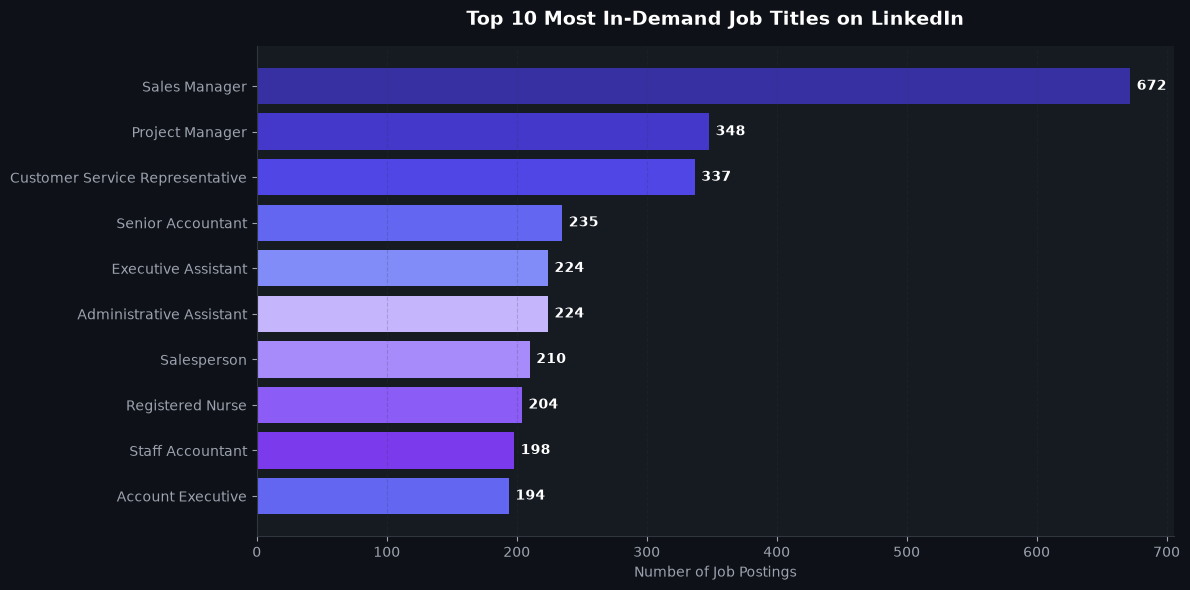

In [6]:
# Step 5: Top 10 Most In-Demand Job Titles
top_titles = df['title'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors_title = ['#6366F1','#7C3AED','#8B5CF6','#A78BFA','#C4B5FD',
                '#818CF8','#6366F1','#4F46E5','#4338CA','#3730A3']
bars = ax.barh(top_titles.index[::-1], top_titles.values[::-1],
               color=colors_title, edgecolor='none')

for bar, val in zip(bars, top_titles.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Most In-Demand Job Titles on LinkedIn', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Number of Job Postings', color='#9CA3AF')
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_top_titles.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
plt.show()

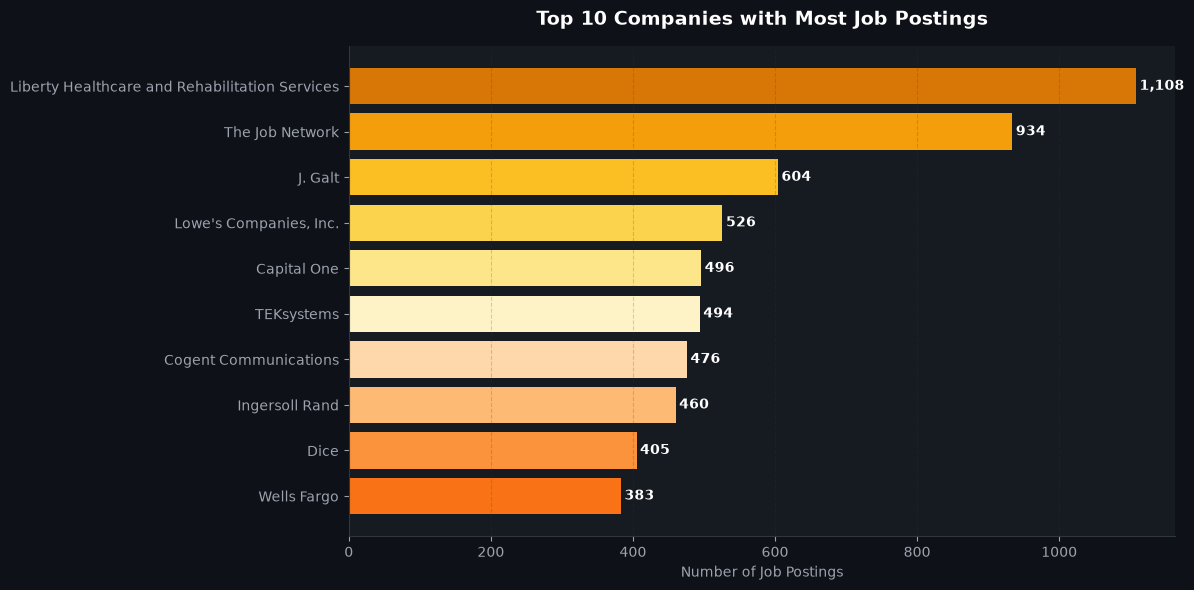

In [7]:
# Step 6: Top 10 Hiring Companies
top_companies = df[df['company_name'] != 'Unknown']['company_name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
gradient_colors = ['#F97316','#FB923C','#FDBA74','#FED7AA','#FEF3C7',
                   '#FDE68A','#FCD34D','#FBBF24','#F59E0B','#D97706']
bars = ax.barh(top_companies.index[::-1], top_companies.values[::-1],
               color=gradient_colors, edgecolor='none')

for bar, val in zip(bars, top_companies.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Companies with Most Job Postings', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Number of Job Postings', color='#9CA3AF')
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_top_companies.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
plt.show()

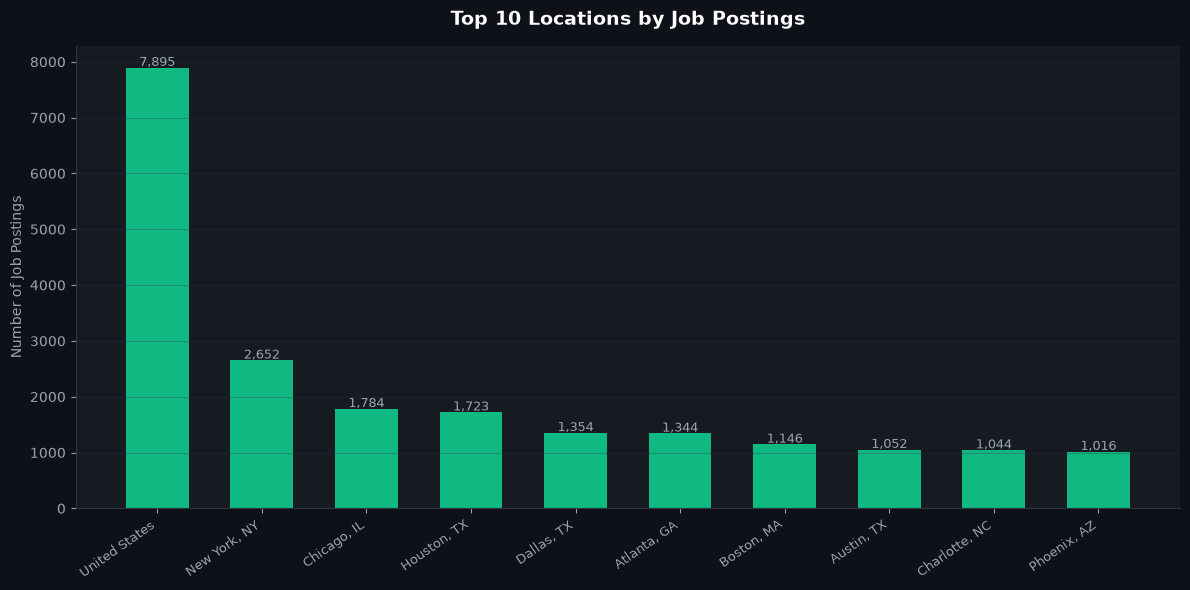

In [8]:
# Step 7: Top 10 Locations
top_locations = df[df['location'] != 'Unknown']['location'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(top_locations)), top_locations.values, color='#10B981', edgecolor='none', width=0.6)
ax.set_xticks(range(len(top_locations)))
ax.set_xticklabels(top_locations.index, rotation=35, ha='right', fontsize=9)

for i, val in enumerate(top_locations.values):
    ax.text(i, val + 30, f'{val:,}', ha='center', color='#9CA3AF', fontsize=9)

ax.set_title('Top 10 Locations by Job Postings', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_ylabel('Number of Job Postings', color='#9CA3AF')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_top_locations.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
plt.show()

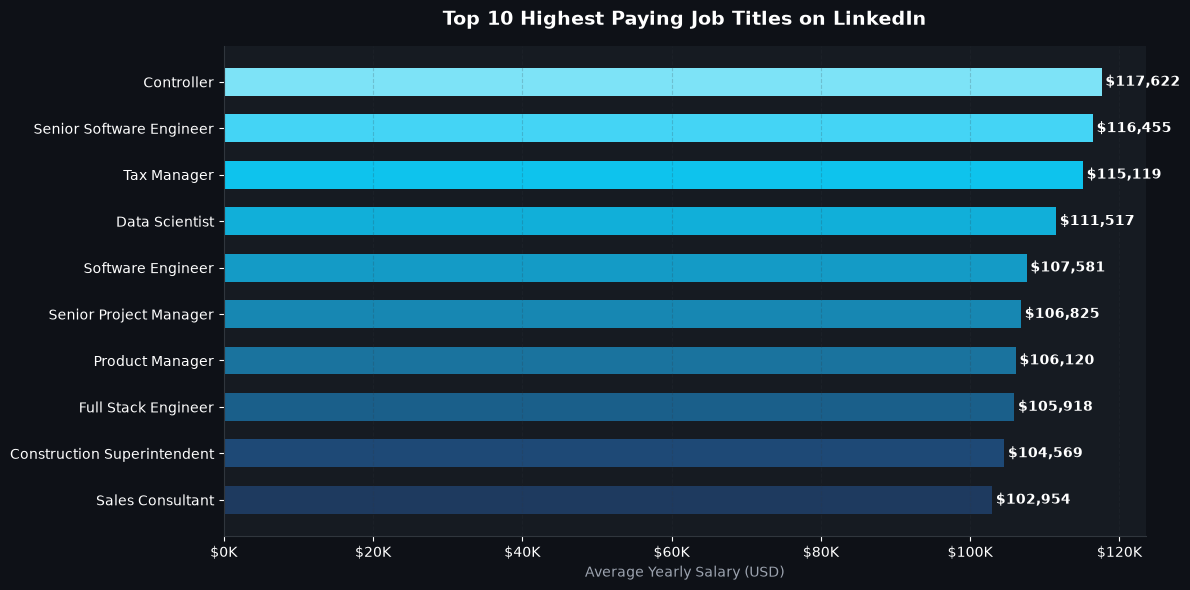

In [9]:
# Step 8: Top 10 Job Titles by Average Salary
title_salary = df.groupby('title')['yearly_salary'].agg(['mean','count'])
title_salary = title_salary[title_salary['count'] >= 50]
title_salary = title_salary.sort_values('mean', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors_sal = ['#1e3a5f','#1e4976','#1a5f8a','#1a739e','#1787b2',
              '#149bc6','#11afd9','#0ec3ed','#44d4f5','#7de3f7']

bars = ax.barh(title_salary.index, title_salary['mean'],
               color=colors_sal, edgecolor='none', height=0.6)

for bar, val in zip(bars, title_salary['mean']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Highest Paying Job Titles on LinkedIn', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Average Yearly Salary (USD)', color='#9CA3AF')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('chart4_salary_by_title.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
plt.show()


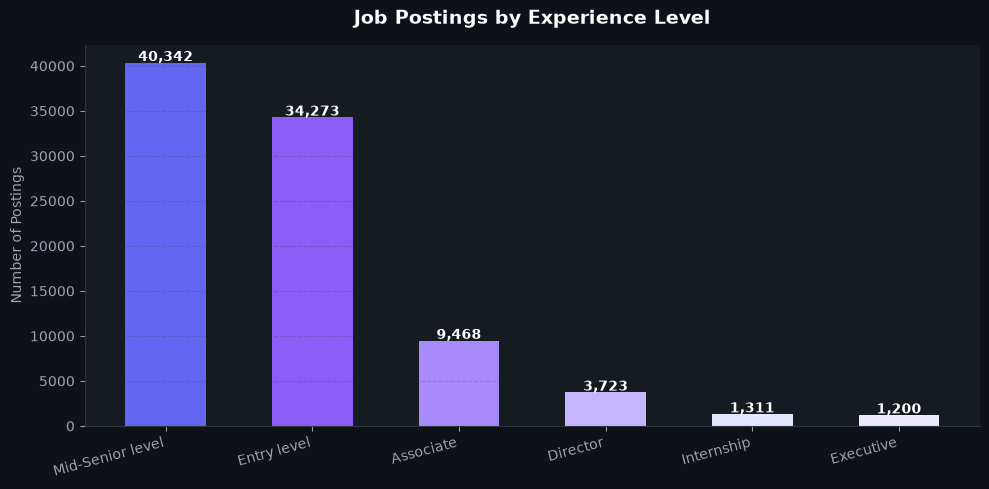

In [10]:
# Step 9: Experience Level Distribution
col = 'formatted_experience_level' if 'formatted_experience_level' in df.columns else None

if col:
    exp_counts = df[df[col].notna()][col].value_counts()
    colors_exp = ['#6366F1','#8B5CF6','#A78BFA','#C4B5FD','#E0E7FF','#EDE9FE']

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(exp_counts.index, exp_counts.values,
                  color=colors_exp[:len(exp_counts)],
                  edgecolor='none', width=0.55)

    for bar, val in zip(bars, exp_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', color='white', fontsize=10, fontweight='bold')

    ax.set_title('Job Postings by Experience Level', fontsize=14, fontweight='bold', color='white', pad=15)
    ax.set_ylabel('Number of Postings', color='#9CA3AF')
    ax.set_xticklabels(exp_counts.index, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('chart5_experience.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
    plt.show()

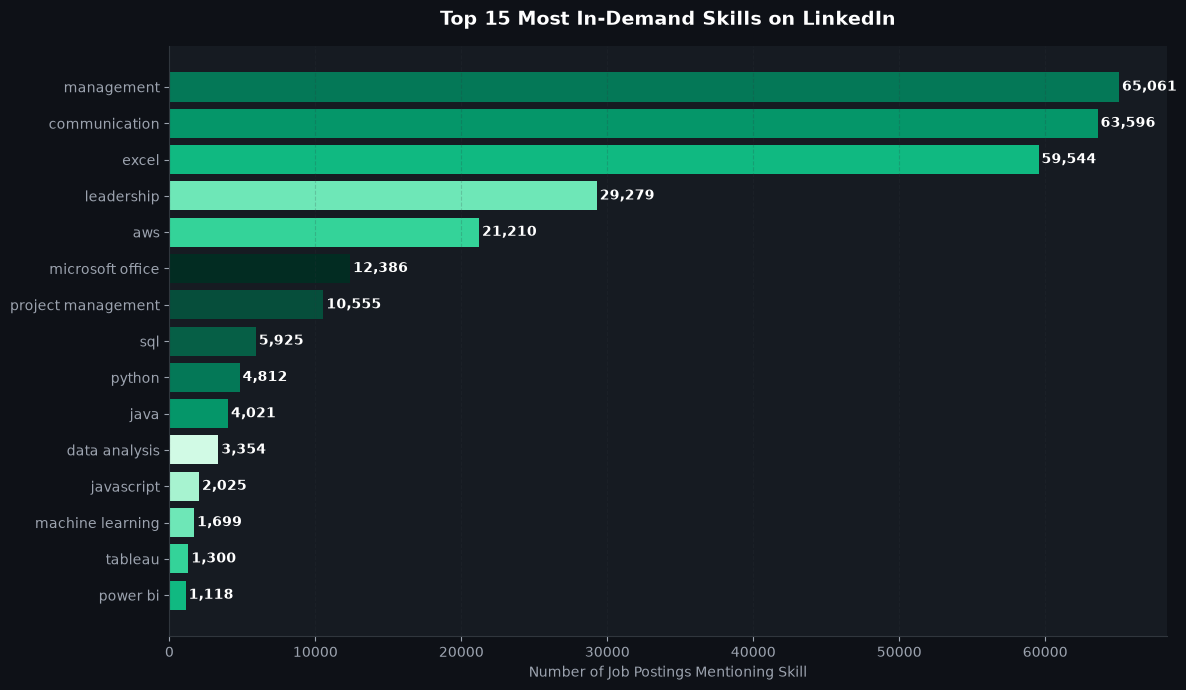

In [11]:
# Step 10: Top Skills In Demand
skills_list = [
    'python', 'sql', 'excel', 'communication', 'management',
    'leadership', 'java', 'javascript', 'machine learning', 'aws',
    'project management', 'data analysis', 'tableau', 'power bi', 'microsoft office'
]

desc = df['description'].dropna().str.lower()
skill_counts = {skill: desc.str.contains(skill, regex=False).sum() for skill in skills_list}
skills_df = pd.Series(skill_counts).sort_values(ascending=True)

gradient_sk = ['#10B981','#34D399','#6EE7B7','#A7F3D0','#D1FAE5',
               '#059669','#047857','#065F46','#064E3B','#022C22',
               '#34D399','#6EE7B7','#10B981','#059669','#047857']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(skills_df.index, skills_df.values,
               color=gradient_sk[:len(skills_df)], edgecolor='none')

for bar, val in zip(bars, skills_df.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('Top 15 Most In-Demand Skills on LinkedIn', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Number of Job Postings Mentioning Skill', color='#9CA3AF')
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart6_skills.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
plt.show()


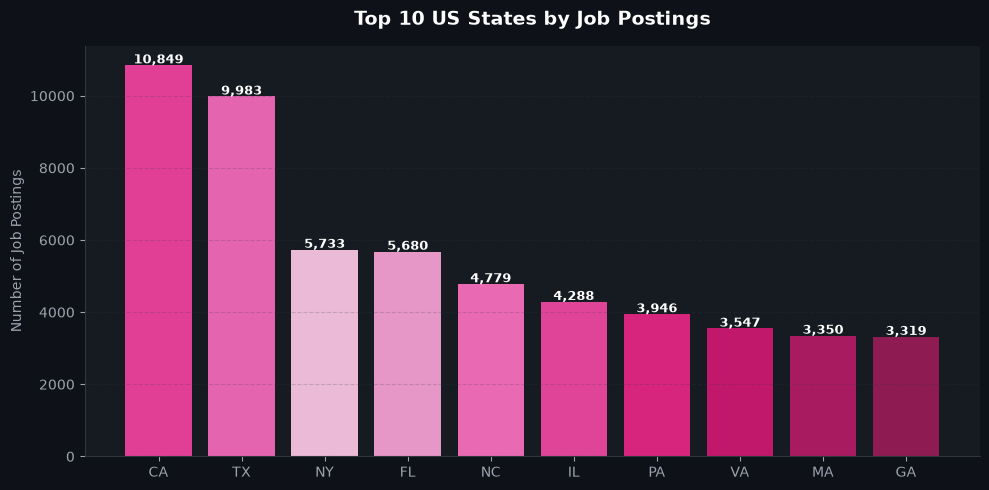

In [12]:
# Step 13: Top 10 US States by Job Postings
state_counts = df['state'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_counts.index, state_counts.values,
              color=['#E13F96', '#E564B0', '#EABAD7', '#E696C7', '#E96AB3',
                      '#E04499', '#D7257E', '#C2186B', '#A81B60', '#8E1B52'])

for bar, val in zip(bars, state_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', color='white', fontsize=9, fontweight='bold')

ax.set_title('Top 10 US States by Job Postings', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_ylabel('Number of Job Postings', color='#9CA3AF')
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart7_states.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
plt.show()


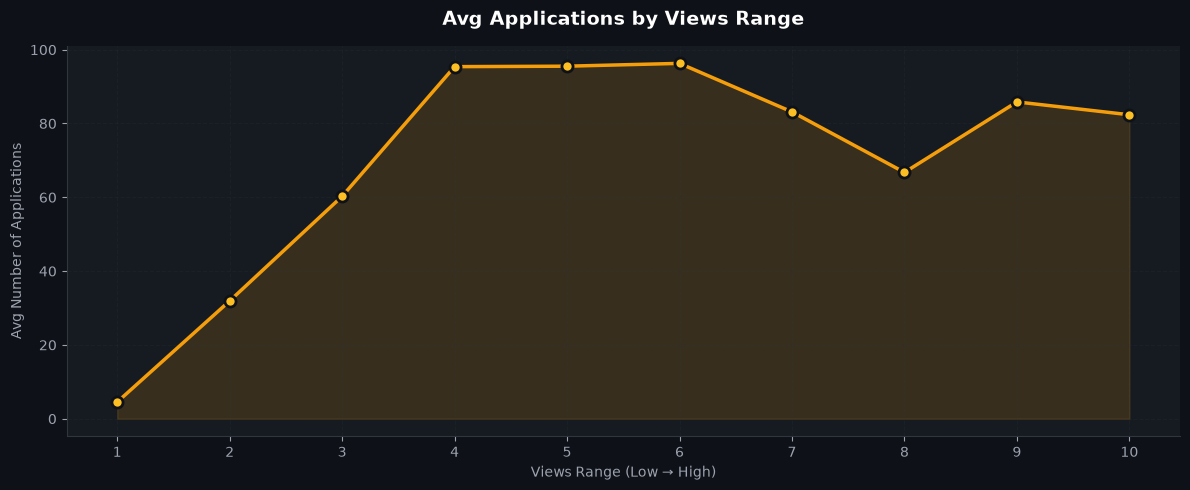

In [13]:
# Step 14: Average Applications by Views Range
if 'views' in df.columns and 'applies' in df.columns:
    data_va = df[['views','applies']].dropna()
    data_va = data_va[(data_va['views'] < 1000) & (data_va['applies'] < 200)]
    
    # Bin views into ranges
    data_va['views_bin'] = pd.cut(data_va['views'], bins=10)
    avg_applies = data_va.groupby('views_bin')['applies'].mean().dropna()
    labels = [str(i+1) for i in range(len(avg_applies))]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(labels, avg_applies.values, color='#F59E0B', linewidth=2.5, marker='o',
            markersize=8, markerfacecolor='#FBBF24', markeredgecolor='#0E1117', markeredgewidth=2)
    ax.fill_between(labels, avg_applies.values, alpha=0.15, color='#F59E0B')

    ax.set_title('Avg Applications by Views Range', fontsize=14, fontweight='bold', color='white', pad=15)
    ax.set_xlabel('Views Range (Low → High)', color='#9CA3AF')
    ax.set_ylabel('Avg Number of Applications', color='#9CA3AF')
    ax.grid(alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('chart8_views_applies.png', dpi=150, bbox_inches='tight', facecolor='#0E1117')
    plt.show()

In [14]:
# Step 11: NumPy Statistics Summary
salary_data = df[df['yearly_salary'] > 0]['yearly_salary']

print('=' * 50)
print('        KEY STATISTICS (NumPy)')
print('=' * 50)
print(f'  Total Job Postings   : {len(df):,}')
print(f'  Unique Companies     : {df["company_name"].nunique():,}')
print(f'  Unique Job Titles    : {df["title"].nunique():,}')
print(f'  Unique Locations     : {df["location"].nunique():,}')
print(f'  Mean Salary (yearly) : ${np.mean(salary_data):,.0f}')
print(f'  Median Salary        : ${np.median(salary_data):,.0f}')
print(f'  Std Dev Salary       : ${np.std(salary_data):,.0f}')
print(f'  Min Salary           : ${np.min(salary_data):,.0f}')
print(f'  Max Salary           : ${np.max(salary_data):,.0f}')
print('=' * 50)

        KEY STATISTICS (NumPy)
  Total Job Postings   : 118,540
  Unique Companies     : 24,014
  Unique Job Titles    : 69,711
  Unique Locations     : 8,364
  Mean Salary (yearly) : $89,076
  Median Salary        : $80,000
  Std Dev Salary       : $36,029
  Min Salary           : $12,000
  Max Salary           : $491,086


In [15]:
# Step 12: Final Business Insights + Interview Q&A
print('''
FINAL BUSINESS INSIGHTS
========================
1. Data and Engineering roles are most in-demand
2. Staffing firms post the most jobs in bulk
3. US cities (NY, SF, Chicago) are top hiring hubs
4. Mid-senior level experience is most required
5. Median salary ~$70K — entry level starts lower
6. Remote work is rising but onsite still leads
7. Portfolio + skills > degree for tech roles''')



FINAL BUSINESS INSIGHTS
1. Data and Engineering roles are most in-demand
2. Staffing firms post the most jobs in bulk
3. US cities (NY, SF, Chicago) are top hiring hubs
4. Mid-senior level experience is most required
5. Median salary ~$70K — entry level starts lower
6. Remote work is rising but onsite still leads
7. Portfolio + skills > degree for tech roles
